# Hyperparameter tuning using the Fashion MNIST dataset
We will train and evaluate an MLP on the Fashion MNIST dataset. It consists of 70.000 grayscale images of 28x28 pixels each, and there are 10 classes.

Hyperparameters:
1. Optimizer: Momentum optimization
2. Activation function: SELU
3. Weight initialization: LeCun

## Setup

In [1]:
# Common imports
import os
import numpy as np
import pandas as pd
import keras

# Select backend. Default is "tensorflow". Alternatives are "jax" and "torch".
os.environ["KERAS_BACKEND"] = "tensorflow"

# To plot pretty figures
%matplotlib inline
import matplotlib.pyplot as plt

## Load the data

In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [3]:
# Split the full training set into a validation set and a (smaller) training set.
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

## Standardize the data
Because we want to use the SELU activation function and LeCun weight initializer, we should standardize all the input features to a mean of 0 and a standard deviation of 1. Since each pixel is an input feature, there are 28x28=784 input features, and we need to compute the mean and standard deviation for each of them.

In [4]:
X_train.shape

(55000, 28, 28)

In [5]:
# Compute the mean for each pixel over the whole training set.
pixel_means = X_train.mean(axis=0)
pixel_means.shape

(28, 28)

In [6]:
# Compute the standard deviation for each pixel over the whole training set.
pixel_stds = X_train.std(axis=0)
pixel_stds.shape

(28, 28)

In [7]:
# Scale the inputs to mean 0 and standard deviation 1 to achieve self-normalization with SELU and LeCun.
X_train_standardized = (X_train - pixel_means) / pixel_stds

X_valid_standardized = (X_valid - X_valid.mean(axis=0)) / X_valid.std(axis=0)
X_test_standardized = (X_test - X_test.mean(axis=0)) / X_test.std(axis=0)

In [8]:
# Validate that the mean is close to 0 for each pixel.
X_train_standardized.mean(axis=0)

array([[ 2.02095556e-15,  1.62754053e-15,  4.46262219e-16,
         1.14067644e-15, -7.41440495e-16, -2.63235242e-15,
        -1.34868732e-15, -2.60230625e-15,  1.66292233e-16,
         6.41022589e-16,  1.30749956e-16, -1.75860942e-15,
         1.77240041e-16, -4.50241864e-16,  5.90933363e-16,
        -7.87533675e-16,  2.07429427e-15, -2.87339849e-16,
        -4.16042958e-16, -6.74107235e-17,  2.68472416e-15,
        -2.27123371e-16, -5.26867943e-16, -1.31060062e-15,
        -2.53719217e-15, -4.31397342e-17,  1.73844777e-16,
         1.29615371e-15],
       [ 3.54259040e-15, -7.59241659e-16,  4.87038213e-15,
        -8.00087774e-16, -1.62997292e-15,  7.67104562e-16,
         1.68777820e-15, -2.78451504e-15,  6.71137893e-16,
        -2.99043013e-15, -2.08019057e-15,  7.63978779e-16,
         7.48899932e-16,  1.82329707e-15, -5.25664361e-16,
        -9.88134826e-16,  9.29450456e-16, -5.45922903e-16,
        -1.89077037e-16,  4.06024709e-16, -7.56264748e-16,
         5.24574323e-16, -5.09

In [9]:
# Validate that the standard deviation is close to 1 for each pixel.
X_train_standardized.std(axis=0)

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1

## Create a model using the Sequential API

In [10]:
model = keras.models.Sequential()
# Input layer:
model.add(keras.layers.Flatten(input_shape=[28, 28]))

# Hidden layers:
for layer in range(3):
    model.add(keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"))
    
# Output layer.
model.add(keras.layers.Dense(10, activation="softmax"))

/Users/hk/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Compile the model
You must at least specify the loss function and the optimizer to use. You can also specify a list of additional metrics to use during training and evaluation.

In [11]:
# The optimixer is Stochastic Gradient Descent with momentum optimization. The momentum is set to 0.9.
# This value usually works well in practice. We use the default learning rate (0.01).
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(momentum=0.9),
              metrics=["accuracy"])

## Train the model

In [12]:
# EarlyStopping (with rollback to the best model).
early_stopping = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

# Train the model with early stopping.
history = model.fit(X_train_standardized, y_train, epochs=40,
                    validation_data=(X_valid_standardized, y_valid),
                    callbacks=[early_stopping])

Epoch 1/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 460us/step - accuracy: 0.7883 - loss: 0.6131 - val_accuracy: 0.8654 - val_loss: 0.3813
Epoch 2/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 432us/step - accuracy: 0.8655 - loss: 0.3720 - val_accuracy: 0.8660 - val_loss: 0.3759
Epoch 3/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 428us/step - accuracy: 0.8789 - loss: 0.3260 - val_accuracy: 0.8638 - val_loss: 0.3751
Epoch 4/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 430us/step - accuracy: 0.8874 - loss: 0.2986 - val_accuracy: 0.8730 - val_loss: 0.3619
Epoch 5/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 432us/step - accuracy: 0.8939 - loss: 0.2861 - val_accuracy: 0.8670 - val_loss: 0.4093
Epoch 6/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 436us/step - accuracy: 0.8999 - loss: 0.2649 - val_accuracy: 0.8844 - val_loss: 0.3255
Epoch 7/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 438us/step - accuracy: 0.9052 - loss: 0.2524 - val_accuracy: 0.8870 - val_loss: 0.3519
Epoch 8/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 439us/step - accuracy: 0.9124 -

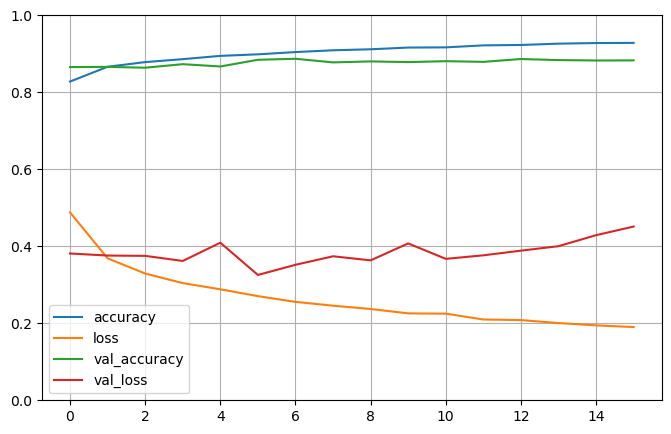

In [13]:
# Show the learning curves.
# (The training curves should be shifted half an epoch to the left to be completely comparable with
# the validation curves).

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

## Evaluate the model.

In [14]:
model.evaluate(X_test_standardized, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 243us/step - accuracy: 0.8751 - loss: 0.3670


[0.37077316641807556, 0.8751999735832214]